# Primeira Exploração

In [56]:
import pandas as pd
import numpy as np

In [57]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [58]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(1470, 35)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork

In [59]:
categorias = df.select_dtypes(include='object').columns.tolist()
numericas = df.select_dtypes(include='number').columns.tolist()

In [60]:
print("Categóricas: ", categorias)
print("Numéricas: ", numericas)

Categóricas:  ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Numéricas:  ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [61]:
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

In [62]:
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)
attition_rate = df['Attrition_bin'].mean()
print(f"Taxa de attrition: {attition_rate:.1%}")

Taxa de attrition: 16.1%


# EDA com Pandas e Seaborn

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 130
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [65]:
df.drop(columns=["EmployeeCount", "Over18", "StandardHours"], inplace=True)

In [66]:
df["Attrition_bin"] = (df["Attrition"] == "Yes").astype(int)

In [67]:
ordinal_cols = {
    "Education":        {1:"Below College", 2:"College", 3:"Bachelor", 4:"Master", 5:"Doctor"},
    "EnvironmentSatisfaction": {1:"Low", 2:"Medium", 3:"High", 4:"Very High"},
    "JobInvolvement":   {1:"Low", 2:"Medium", 3:"High", 4:"Very High"},
    "JobSatisfaction":  {1:"Low", 2:"Medium", 3:"High", 4:"Very High"},
    "PerformanceRating":{1:"Low", 2:"Good", 3:"Excellent", 4:"Outstanding"},
    "RelationshipSatisfaction":{1:"Low",2:"Medium",3:"High",4:"Very High"},
    "WorkLifeBalance":  {1:"Bad", 2:"Good", 3:"Better", 4:"Best"},
}

In [68]:
for col, mapping in ordinal_cols.items():
    df[col + "_label"] = df[col].map(mapping)

print(df.shape)
print(df.dtypes)

(1470, 40)
Age                                int64
Attrition                         object
BusinessTravel                    object
DailyRate                          int64
Department                        object
DistanceFromHome                   int64
Education                          int64
EducationField                    object
EmployeeNumber                     int64
EnvironmentSatisfaction            int64
Gender                            object
HourlyRate                         int64
JobInvolvement                     int64
JobLevel                           int64
JobRole                           object
JobSatisfaction                    int64
MaritalStatus                     object
MonthlyIncome                      int64
MonthlyRate                        int64
NumCompaniesWorked                 int64
OverTime                          object
PercentSalaryHike                  int64
PerformanceRating                  int64
RelationshipSatisfaction           int64
Stock

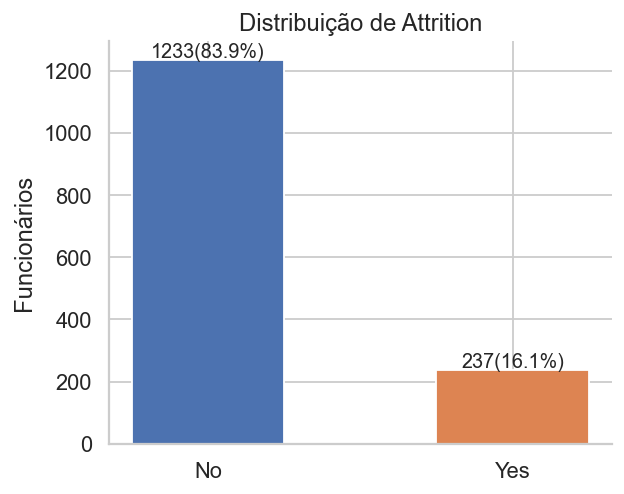

In [69]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Attrition"].value_counts()
ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"], width=0.5)

for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    ax.text(i, val + 10, f"{val}({val/len(df):.1%})", ha="center", fontsize=11)

ax.set_title("Distribuição de Attrition")
ax.set_ylabel("Funcionários")
sns.despine()
plt.tight_layout()
plt.savefig("../assets/01_attrition_dist.png")
plt.show()

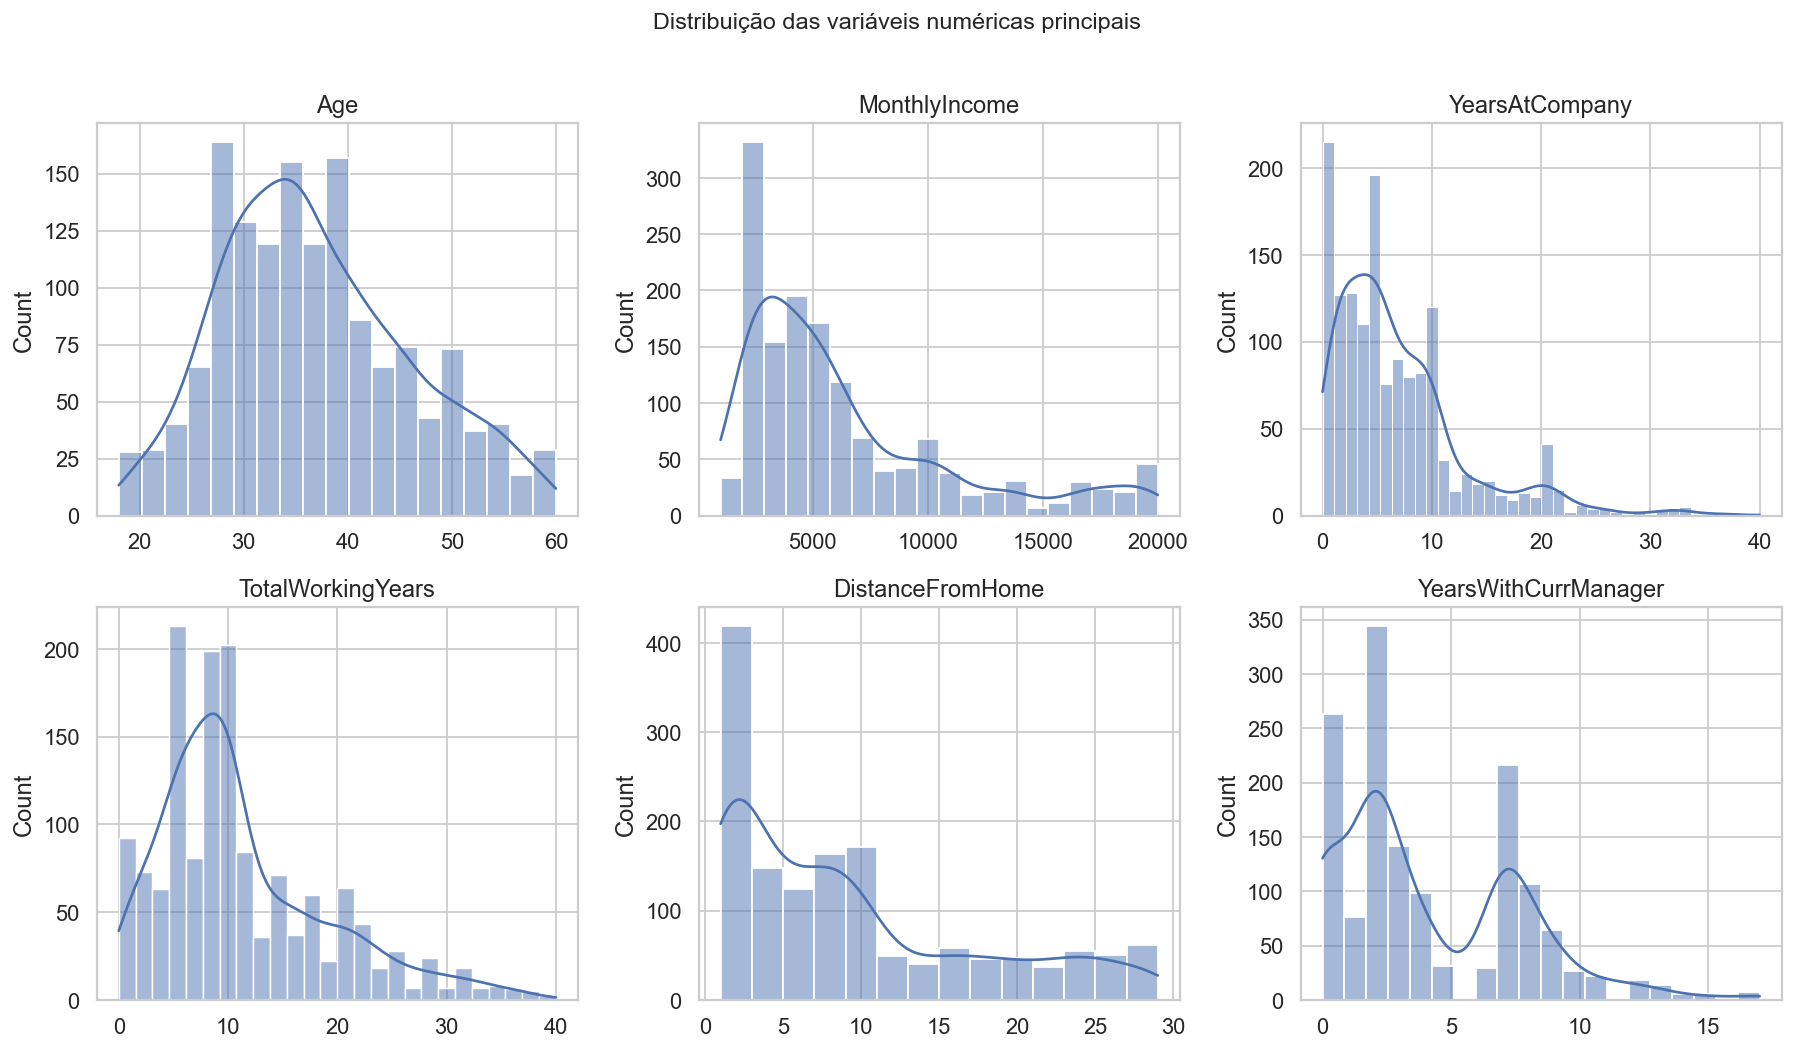

In [70]:
num_cols = ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears", "DistanceFromHome", "YearsWithCurrManager"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Distribuição das variáveis numéricas principais", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig("../assets/02_distributions.png")
plt.show()

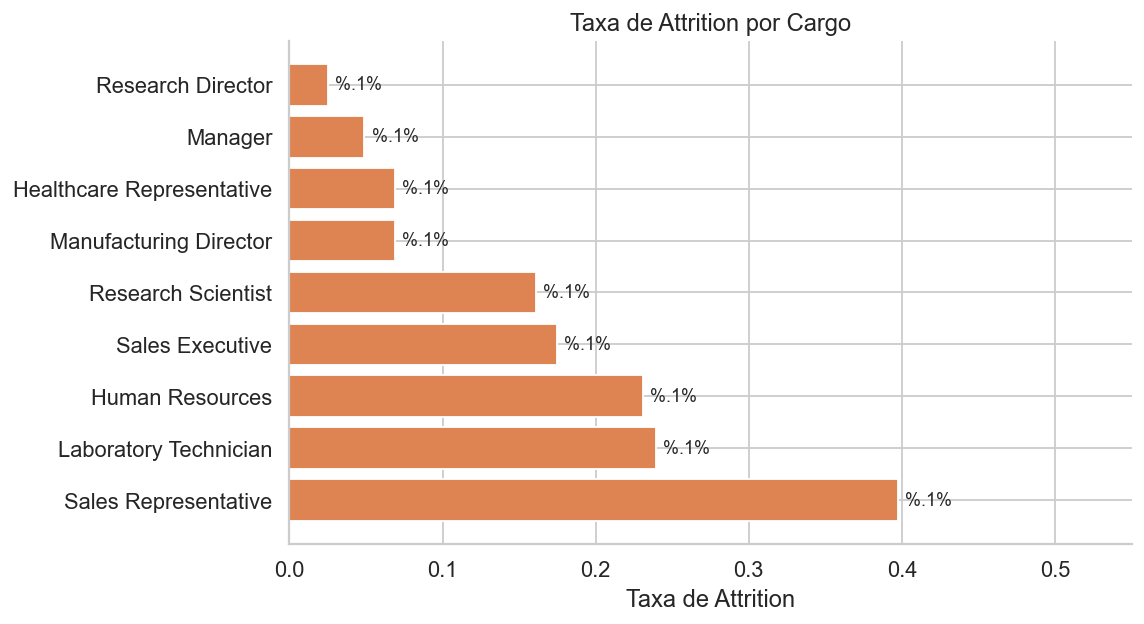

In [71]:
role_attr = (df.groupby("JobRole")["Attrition_bin"]
             .mean()
             .sort_values(ascending=False)
             .reset_index())
role_attr.columns = ["JobRole", "AttritionRate"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(role_attr["JobRole"], role_attr["AttritionRate"],
               color="#DD8452")
ax.bar_label(bars, fmt="%.1%", padding=4, fontsize=10)
ax.set_xlabel("Taxa de Attrition")
ax.set_title("Taxa de Attrition por Cargo")
ax.set_xlim(0, 0.55)
sns.despine()
plt.tight_layout()
plt.savefig("../assets/03_attrition_jobrole.png")
plt.show()

C:\Users\JOAO\AppData\Local\Temp\ipykernel_18868\1526432874.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




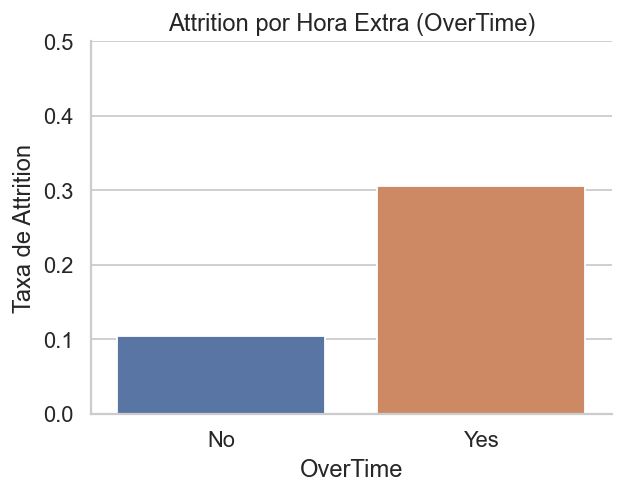

In [72]:
ot = df.groupby("OverTime")["Attrition_bin"].mean().reset_index()

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(data=ot, x="OverTime", y="Attrition_bin",
            palette=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Attrition por Hora Extra (OverTime)")
ax.set_ylabel("Taxa de Attrition")
ax.set_ylim(0, 0.5)
sns.despine()
plt.tight_layout()
plt.savefig("../assets/04_attrition_overtime.png")
plt.show()

C:\Users\JOAO\AppData\Local\Temp\ipykernel_18868\1283434093.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




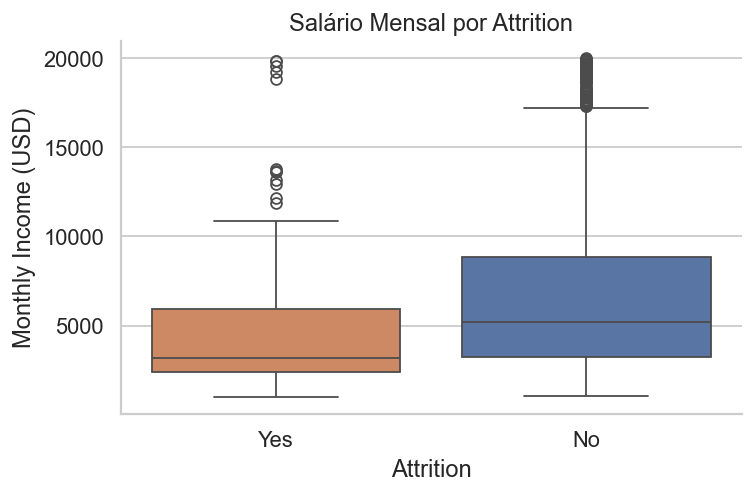

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome",
            palette={"No": "#4C72B0", "Yes": "#DD8452"}, ax=ax)
ax.set_title("Salário Mensal por Attrition")
ax.set_ylabel("Monthly Income (USD)")
sns.despine()
plt.tight_layout()
plt.savefig("../assets/05_income_attrition.png")
plt.show()

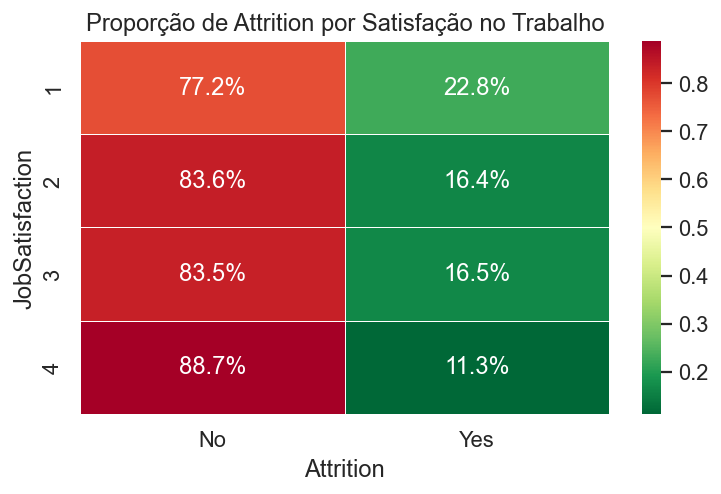

In [74]:
pivot = (df.groupby(["JobSatisfaction", "Attrition"])
         .size()
         .unstack()
         .apply(lambda x: x / x.sum(), axis=1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax)
ax.set_title("Proporção de Attrition por Satisfação no Trabalho")
plt.tight_layout()
plt.savefig("../assets/06_satisfaction_heatmap.png")
plt.show()

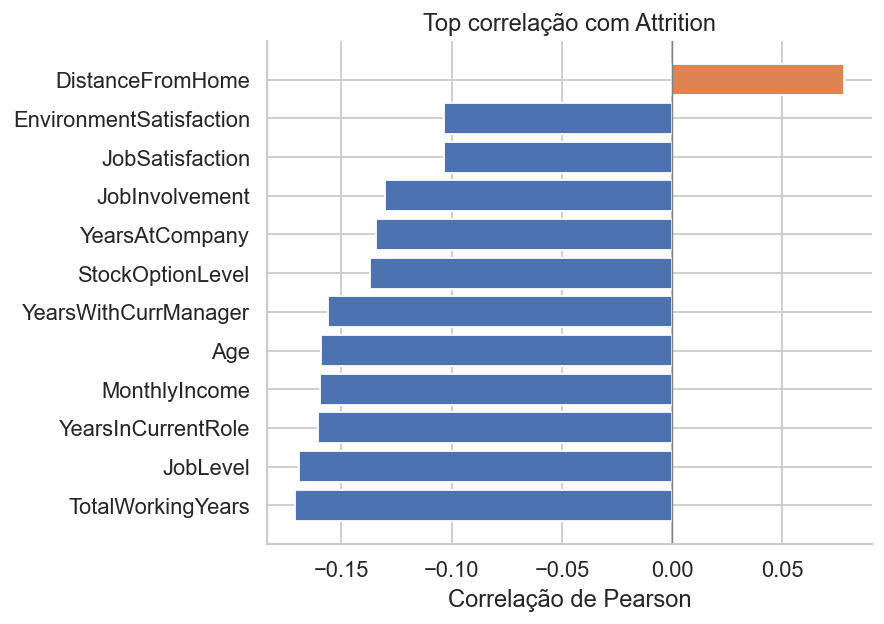

In [75]:
numericas = df.select_dtypes(include="number").drop(
    columns=["EmployeeNumber"], errors='ignore'
)

corr = numericas.corr()

attrition_corr = (corr['Attrition_bin']
                  .drop("Attrition_bin")
                  .sort_values(key=abs, ascending=False)
                  .head(12))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in attrition_corr]
ax.barh(attrition_corr.index, attrition_corr.values, color=colors)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_title("Top correlação com Attrition")
ax.set_xlabel("Correlação de Pearson")
sns.despine()
plt.tight_layout()
plt.savefig("../assets/07_correlations.png")
plt.show()

# Visualizações interativas com Plotly

In [76]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [77]:
# Paleta de cores

COLORS = {
    "No":      "#4C72B0",
    "Yes":     "#DD8452",
    "primary": "#4C72B0",
    "seq":     "Blues",
}

In [78]:
fig = px.sunburst(
    df,
    path=["Department", "JobRole", "Attrition"],
    title="Attrition por Departamento e Cargo",
    color="Attrition",
    color_discrete_map=COLORS,
)

fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show(renderer="browser")
#fig.show()

In [79]:
fig = px.scatter(
    df,
    x="Age",
    y="MonthlyIncome",
    color="Attrition",
    symbol="Gender",
    hover_data=["JobRole", "Department", "YearsAtCompany"],
    color_discrete_map=COLORS,
    opacity=0.7,
    title="Salário x Idade x Attrition",
    labels={"MonthlyIncome": "Salário Mensal (USD)", "Age": "Idade"},
)

fig.update_layout(legend_title_text="Attrition")
fig.show(renderer="browser")
#fig.show()

In [80]:
df["SalaryBand"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 3000, 6000, 10000, 20000],
    labels=["< 3k", "3k-6k", "6k-10k", "> 10k"]
)

band_attr = (df.groupby("SalaryBand", observed=True)["Attrition_bin"]
             .mean()
             .reset_index())
band_attr.columns = ["SalaryBand","AttritionRate"]

fig = px.bar(
    band_attr,
    x="SalaryBand",
    y="AttritionRate",
    text_auto=".1%",
    color="AttritionRate",
    color_continuous_scale="Oranges",
    title="Taxa de Attrition por Faixa Salarial",
    labels={"AttritionRate": "Taxa de Attrition", "SalaryBand": "Faixa Salarial"},

)

fig.update_layout(coloraxis_showscale=False)
fig.show(renderer="browser")
#fig.show()

In [81]:
pivot = (df.groupby(["JobSatisfaction", "WorkLifeBalance"])["Attrition_bin"]
         .mean()
         .reset_index())
pivot.columns = ["JobSatisfaction", "WorkLifeBalance", "AttritionRate"]

fig = px.density_heatmap(
    pivot,
    x="WorkLifeBalance",
    y="JobSatisfaction",
    z="AttritionRate",
    color_continuous_scale="RdYlGn_r",
    text_auto=".1%",
    title="Taxa de Attrition: Satisfação × Equilíbrio Vida-Trabalho",
    labels={
        "AttritionRate": "Taxa",
        "JobSatisfaction": "Satisfação no Trabalho",
        "WorkLifeBalance": "Work-Life Balance",
    },
)
fig.show(renderer="browser")
#fig.show()

In [82]:
fig = px.box(
    df,
    x="Attrition",
    y="YearsAtCompany",
    color="Attrition",
    color_discrete_map=COLORS,
    points="outliers",
    title="Anos na Empresa por Attrition",
    labels={"YearsAtCompany": "Anos na Empresa"},
)

fig.update_layout(showlegend=False)
fig.show(renderer="browser")
#fig.show()

In [83]:
fatores = {
    "Base (média geral)": 0.161,
    "+ OverTime = Yes": 0.153,
    "+ Salário < 3k": 0.089,
    "+ JobRole: Sales Rep": 0.061,
    "+ Solteiro": 0.047,
    "+ Distância > 20km": 0.031,
}

fig = go.Figure(go.Waterfall(
    name="Risco",
    orientation="v",
    measure=["absolute"] + ["relative"] * (len(fatores) - 1),
    x=list(fatores.keys()),
    y=list(fatores.values()),
    text=[f"+{v:.1%}" if i > 0 else f"{v:.1%}" for i, v in enumerate(fatores.values())],
    textposition="outside",
    connector={"line": {"color": "gray", "dash": "dot"}},
    increasing={"marker": {"color": "#DD8452"}},
    totals={"marker": {"color": "#4C72B0"}},
))

fig.update_layout(
    title="Fatores de Risco Cumulativo de Attrition",
    yaxis_tickformat=".0%",
    showlegend=False,
)
fig.show(renderer="browser")
#fig.show()